# SVR (Support Vector Regression) — Predicción de Tráfico M30
> Modelo SVR con kernel RBF y normalización Standard. Configuración: 48h y 168h de lag → horizontes 1h, 24h, 168h.
>
> **Estilos:** Ver `documents/Estilos tfm.MD`
>
> ⚠️ **Nota de tiempo de ejecución:** El SVR-RBF puede tardar entre 10-30 minutos en entrenarse.
> Si el tiempo es crítico, usar la celda alternativa con LinearSVR.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# CARGA DE DATOS — splits cronológicos (sin solapamiento)
# ---------------------------------------------------------------------------
ruta_train = '../../data/processed/Split_Datasets/data_train_clean.csv'
ruta_val   = '../../data/processed/Split_Datasets/data_val_clean.csv'
ruta_test  = '../../data/processed/Split_Datasets/data_test_clean.csv'

def preparar_indice_temporal(df):
    """Convierte 'fecha' en índice datetime con frecuencia horaria estricta."""
    df['fecha'] = pd.to_datetime(df['fecha'])
    df.set_index('fecha', inplace=True)
    df.sort_index(inplace=True)
    df = df.asfreq('h')
    return df

df_train = pd.read_csv(ruta_train, parse_dates=['fecha'], index_col='fecha')
df_val   = pd.read_csv(ruta_val,   parse_dates=['fecha'], index_col='fecha')
df_test  = pd.read_csv(ruta_test,  parse_dates=['fecha'], index_col='fecha')

df_train.sort_index(inplace=True)
df_val.sort_index(inplace=True)
df_test.sort_index(inplace=True)

# ---------------------------------------------------------------------------
# Definición de columnas
# ---------------------------------------------------------------------------
cols_endogenas  = [col for col in df_train.columns
                   if 'intensidad' in col or 'ocupacion' in col or 'vmed' in col]
cols_exogenas   = ['hora', 'dia_semana', 'mes', 'es_finde']
cols_intensidad = [col for col in cols_endogenas if 'intensidad' in col]
sensores        = ['Sensor 3820', 'Sensor 6642', 'Sensor 6676', 'Sensor 6782']
sensor_ids      = ['3820', '6642', '6676', '6782']

print("--- ESTRUCTURA DE DATOS ---")
print(f"Train : {df_train.shape} | {df_train.index.min()} → {df_train.index.max()}")
print(f"Val   : {df_val.shape}   | {df_val.index.min()} → {df_val.index.max()}")
print(f"Test  : {df_test.shape}  | {df_test.index.min()} → {df_test.index.max()}")
print(f"\nVariables objetivo (intensidad): {cols_intensidad}")


--- ESTRUCTURA DE DATOS ---
Train : (16080, 16) | 2024-01-01 00:00:00 → 2025-10-31 23:00:00
Val   : (1464, 16)   | 2025-11-01 00:00:00 → 2025-12-31 23:00:00
Test  : (1416, 16)  | 2026-01-01 00:00:00 → 2026-02-28 23:00:00

Variables objetivo (intensidad): ['intensidad_3820', 'intensidad_6642', 'intensidad_6676', 'intensidad_6782']


## 2. Imputación y Variables de Calendario

In [2]:
def limpiar_nulos(df, cols_endo):
    """Imputa nulos por interpolación lineal y reconstruye variables de calendario."""
    df[cols_endo] = df[cols_endo].interpolate(method='linear', limit_direction='both')
    df['hora']       = df.index.hour
    df['dia_semana'] = df.index.dayofweek
    df['mes']        = df.index.month
    df['es_finde']   = (df['dia_semana'] >= 5).astype(int)
    return df

df_train = limpiar_nulos(df_train, cols_endogenas)
df_val   = limpiar_nulos(df_val,   cols_endogenas)
df_test  = limpiar_nulos(df_test,  cols_endogenas)

nulos_total = (df_train.isnull().sum().sum() +
               df_val.isnull().sum().sum()   +
               df_test.isnull().sum().sum())
print(f"✅ Nulos totales tras imputación: {nulos_total}")


✅ Nulos totales tras imputación: 0


## 3. Construcción del Dataset Supervisado y Normalización

In [3]:
def crear_dataset_supervisado(df, cols_target, cols_exog, window_size):
    """
    Transforma la serie temporal en un problema de regresión supervisada.
    X = [valores de cols_target en t-window_size … t-1] + [variables exógenas en t]
    y = [valores de cols_target en t]
    """
    X_list, y_list = [], []
    datos_target = df[cols_target].values
    datos_exog   = df[cols_exog].values
    for i in range(window_size, len(df)):
        ventana  = datos_target[i - window_size : i].flatten()
        contexto = datos_exog[i]
        X_list.append(np.concatenate([ventana, contexto]))
        y_list.append(datos_target[i])
    return np.array(X_list), np.array(y_list)
from sklearn.preprocessing import StandardScaler

lags_a_evaluar    = [48, 168]
horizontes_a_eval = [1, 24, 168]

datasets    = {}   # { lag: (X_tr, y_tr, X_va, y_va, X_te, y_te) }
scalers     = {}   # { lag: (scaler_X, scaler_y) }

for lag in lags_a_evaluar:
    print(f"\nConstruyendo dataset supervisado con ventana={lag}h ...")
    X_tr, y_tr = crear_dataset_supervisado(df_train, cols_intensidad, cols_exogenas, lag)
    X_va, y_va = crear_dataset_supervisado(df_val,   cols_intensidad, cols_exogenas, lag)
    X_te, y_te = crear_dataset_supervisado(df_test,  cols_intensidad, cols_exogenas, lag)
    
    # CRÍTICO: fit() sólo sobre train
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_tr_sc = scaler_X.fit_transform(X_tr)
    y_tr_sc = scaler_y.fit_transform(y_tr)
    X_va_sc = scaler_X.transform(X_va)
    X_te_sc = scaler_X.transform(X_te)
    
    datasets[lag] = (X_tr_sc, y_tr_sc, X_va_sc, X_te_sc, X_tr, y_tr)
    scalers[lag]  = (scaler_X, scaler_y)
    print(f"  ✅ X_train: {X_tr.shape} | Normalización completada")



Construyendo dataset supervisado con ventana=48h ...
  ✅ X_train: (16032, 196) | Normalización completada

Construyendo dataset supervisado con ventana=168h ...
  ✅ X_train: (15912, 676) | Normalización completada


## 4. Entrenamiento SVR-RBF — lag=48h y lag=168h

In [4]:
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
import time

modelos_svr = {}  # { lag: modelo_svr }

for lag in lags_a_evaluar:
    X_tr_sc, y_tr_sc, X_va_sc, X_te_sc, X_tr_raw, y_tr_raw = datasets[lag]
    
    svr_base    = SVR(kernel='rbf', C=100, epsilon=0.1, gamma='scale')
    modelo_svr  = MultiOutputRegressor(svr_base, n_jobs=-1)
    
    print(f"\n⏳ Entrenando SVR-RBF (lag={lag}h) — puede tardar varios minutos...")
    t0 = time.time()
    modelo_svr.fit(X_tr_sc, y_tr_sc)
    t1 = time.time()
    print(f"  ✅ SVR-{lag}h entrenado en {(t1-t0)/60:.1f} minutos.")
    modelos_svr[lag] = modelo_svr



⏳ Entrenando SVR-RBF (lag=48h) — puede tardar varios minutos...
  ✅ SVR-48h entrenado en 6.1 minutos.

⏳ Entrenando SVR-RBF (lag=168h) — puede tardar varios minutos...
  ✅ SVR-168h entrenado en 12.5 minutos.


## 4b. Alternativa: LinearSVR (más rápido)

Ejecutar esta celda **en lugar de la anterior** si SVR-RBF es demasiado lento.

In [ ]:
# ---------------------------------------------------------------------------
# ALTERNATIVA MÁS RÁPIDA: LinearSVR
# Descomentar y ejecutar en lugar de la celda anterior si es necesario
# ---------------------------------------------------------------------------
# from sklearn.svm import LinearSVR
# import time
#
# for lag in lags_a_evaluar:
#     X_tr_sc, y_tr_sc, _, _, _, _ = datasets[lag]
#     svr_lineal = LinearSVR(C=1.0, epsilon=0.1, max_iter=2000)
#     modelo_svr = MultiOutputRegressor(svr_lineal, n_jobs=-1)
#     print(f"\n⏳ Entrenando LinearSVR (lag={lag}h)...")
#     t0 = time.time()
#     modelo_svr.fit(X_tr_sc, y_tr_sc)
#     t1 = time.time()
#     modelos_svr[lag] = modelo_svr
#     print(f"  ✅ LinearSVR-{lag}h entrenado en {(t1-t0)/60:.1f} minutos.")

print("(Celda alternativa — descomentar para ejecutar LinearSVR)")


## Configuracion nueva

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calcular_metricas(y_real, y_pred, horizonte_h):
    """Calcula RMSE, MAE y R² para cada sensor."""
    resultados = {}
    for j, sensor in enumerate(sensores):
        real_j = y_real[:, j]
        pred_j = y_pred[:, j]
        mask = ~np.isnan(real_j) & ~np.isnan(pred_j)
        rmse = np.sqrt(mean_squared_error(real_j[mask], pred_j[mask]))
        mae  = mean_absolute_error(real_j[mask], pred_j[mask])
        r2   = r2_score(real_j[mask], pred_j[mask]) if mask.sum() > 1 else None
        resultados[sensor] = {'RMSE': rmse, 'MAE': mae, 'R²': r2}
    return resultados

def imprimir_tabla(resultados_test, nombre_modelo):
    """Imprime la tabla resumen de métricas según Estilos TFM."""
    horizontes_nombres = {1: '1 HORA', 24: '24 HORAS', 168: '168 HORAS'}
    for horizonte in [1, 24, 168]:
        nombre_h = horizontes_nombres[horizonte]
        print(f"\n{'='*58}")
        print(f"  HORIZONTE: {nombre_h} — {nombre_modelo}")
        print(f"{'='*58}")
        print(f"  {'Sensor':<14} {'RMSE':>10} {'MAE':>10} {'R²':>10}")
        print(f"  {'-'*44}")
        rmse_vals, mae_vals, r2_vals = [], [], []
        for sensor in sensores:
            m = resultados_test[horizonte][sensor]
            r2_str = f"{m['R²']:>10.4f}" if m['R²'] is not None else f"{'N/A':>10}"
            print(f"  {sensor:<14} {m['RMSE']:>10.2f} {m['MAE']:>10.2f} {r2_str}")
            rmse_vals.append(m['RMSE'])
            mae_vals.append(m['MAE'])
            if m['R²'] is not None:
                r2_vals.append(m['R²'])
        print(f"  {'-'*44}")
        r2_prom_str = f"{sum(r2_vals)/len(r2_vals):>10.4f}" if r2_vals else f"{'N/A':>10}"
        print(f"  {'PROMEDIO':<14} "
              f"{sum(rmse_vals)/len(rmse_vals):>10.2f} "
              f"{sum(mae_vals)/len(mae_vals):>10.2f} "
              f"{r2_prom_str}")

In [6]:
def predecir_iterativo_svr(modelo, scaler_X, scaler_y, buffer_inicio,
                            df_futuro, cols_target, cols_exog, window_size, steps):
    """
    Predicción iterativa SVR con normalización/desnormalización integrada.
    buffer_inicio: array (window_size, n_targets) con valores reales sin escalar.
    """
    buffer = buffer_inicio.copy()
    predicciones = []
    for i in range(steps):
        exog_i = df_futuro[cols_exog].iloc[i].values
        x_i    = np.concatenate([buffer.flatten(), exog_i]).reshape(1, -1)
        x_i_sc = scaler_X.transform(x_i)
        pred_sc = modelo.predict(x_i_sc)
        pred    = scaler_y.inverse_transform(pred_sc)[0]
        predicciones.append(pred)
        buffer  = np.vstack([buffer[1:], pred])
    return np.array(predicciones)

print("--- GENERANDO PREDICCIONES SOBRE TEST ---")
resultados_test = {}

for lag in lags_a_evaluar:
    scaler_X, scaler_y = scalers[lag]
    buffer_inicio = df_val.iloc[-lag:][cols_intensidad].values

    # Horizonte 1h — inferencia directa sobre todo el test (para R² válido)
    X_te_sc  = datasets[lag][3]
    y_te_raw = df_test[cols_intensidad].values[lag:]
    preds_1h_sc = modelos_svr[lag].predict(X_te_sc)
    preds_1h    = scaler_y.inverse_transform(preds_1h_sc)
    resultados_test[(lag, 1)] = calcular_metricas(y_te_raw, preds_1h, horizonte_h=1)
    print(f"  ✅ SVR-{lag}h → 1h evaluado sobre test (directa, {len(preds_1h)} pasos)")

    # Horizontes 24h y 168h — predicción iterativa (sin cambios)
    for horizonte in [24, 168]:
        preds = predecir_iterativo_svr(
            modelos_svr[lag], scaler_X, scaler_y, buffer_inicio,
            df_test, cols_intensidad, cols_exogenas, lag, steps=horizonte
        )
        y_real = df_test[cols_intensidad].iloc[:horizonte].values
        metricas = calcular_metricas(y_real, preds, horizonte)
        resultados_test[(lag, horizonte)] = metricas
        print(f"  ✅ SVR-{lag}h → {horizonte}h evaluado sobre test")

for lag in lags_a_evaluar:
    print(f"\n{'#'*65}")
    print(f"  SVR-{lag}h — RESULTADOS SOBRE TEST")
    print(f"{'#'*65}")
    resultados_lag = {h: resultados_test[(lag, h)] for h in horizontes_a_eval}
    imprimir_tabla(resultados_lag, f'SVR-{lag}h')

--- GENERANDO PREDICCIONES SOBRE TEST ---
  ✅ SVR-48h → 1h evaluado sobre test (directa, 1368 pasos)
  ✅ SVR-48h → 24h evaluado sobre test
  ✅ SVR-48h → 168h evaluado sobre test
  ✅ SVR-168h → 1h evaluado sobre test (directa, 1248 pasos)
  ✅ SVR-168h → 24h evaluado sobre test
  ✅ SVR-168h → 168h evaluado sobre test

#################################################################
  SVR-48h — RESULTADOS SOBRE TEST
#################################################################

  HORIZONTE: 1 HORA — SVR-48h
  Sensor               RMSE        MAE         R²
  --------------------------------------------
  Sensor 3820        431.67     300.14     0.9469
  Sensor 6642        479.79     325.11     0.9498
  Sensor 6676        456.16     304.85     0.9384
  Sensor 6782        360.57     253.24     0.9583
  --------------------------------------------
  PROMEDIO           432.05     295.84     0.9483

  HORIZONTE: 24 HORAS — SVR-48h
  Sensor               RMSE        MAE         R²
  ------

## 6. Gráficas — Semana 2-8 febrero 2026 (Estilos TFM)

In [7]:
def graficar_semana(df_pred_semana_48, df_pred_semana_168, real_semana, nombre_modelo_base):
    """Genera gráficas 2×2 para 48h y 168h según Estilos TFM."""
    semana_inicio = pd.Timestamp('2026-02-02 00:00:00')
    
    for lag, df_pred_semana in [('48', df_pred_semana_48), ('168', df_pred_semana_168)]:
        nombre_modelo = f'{nombre_modelo_base}({lag}h)'
        fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))
        fig.suptitle(
            f'{nombre_modelo} — Predicción: 2 al 8 de febrero 2026 (168h)',
            fontsize=16, fontweight='bold', y=0.98
        )
        axes = axes.flatten()
        for i, col in enumerate(cols_intensidad):
            ax = axes[i]
            sensor_id = sensor_ids[i]
            ax.plot(
                df_pred_semana.index, df_pred_semana[col],
                color='#ff7f0e', linewidth=2, linestyle='--',
                label=f'Predicción {nombre_modelo}'
            )
            ax.plot(
                real_semana.index, real_semana[col],
                color='#1f77b4', linewidth=2, label='Real (168h)'
            )
            ax.axvline(
                x=semana_inicio, color='grey', linestyle=':',
                linewidth=1.5, label='Inicio predicción'
            )
            ax.set_title(f'Sensor {sensor_id}', fontsize=13, fontweight='bold')
            ax.set_ylabel('Intensidad (veh/h)', fontsize=11)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b\n%Hh'))
            ax.xaxis.set_major_locator(mdates.DayLocator())
            ax.grid(True, linestyle=':', alpha=0.6)
            ax.legend(loc='upper right', fontsize=9)
            ax.tick_params(axis='x', rotation=0)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()
        print(f"✅ Gráfica generada: {nombre_modelo}")


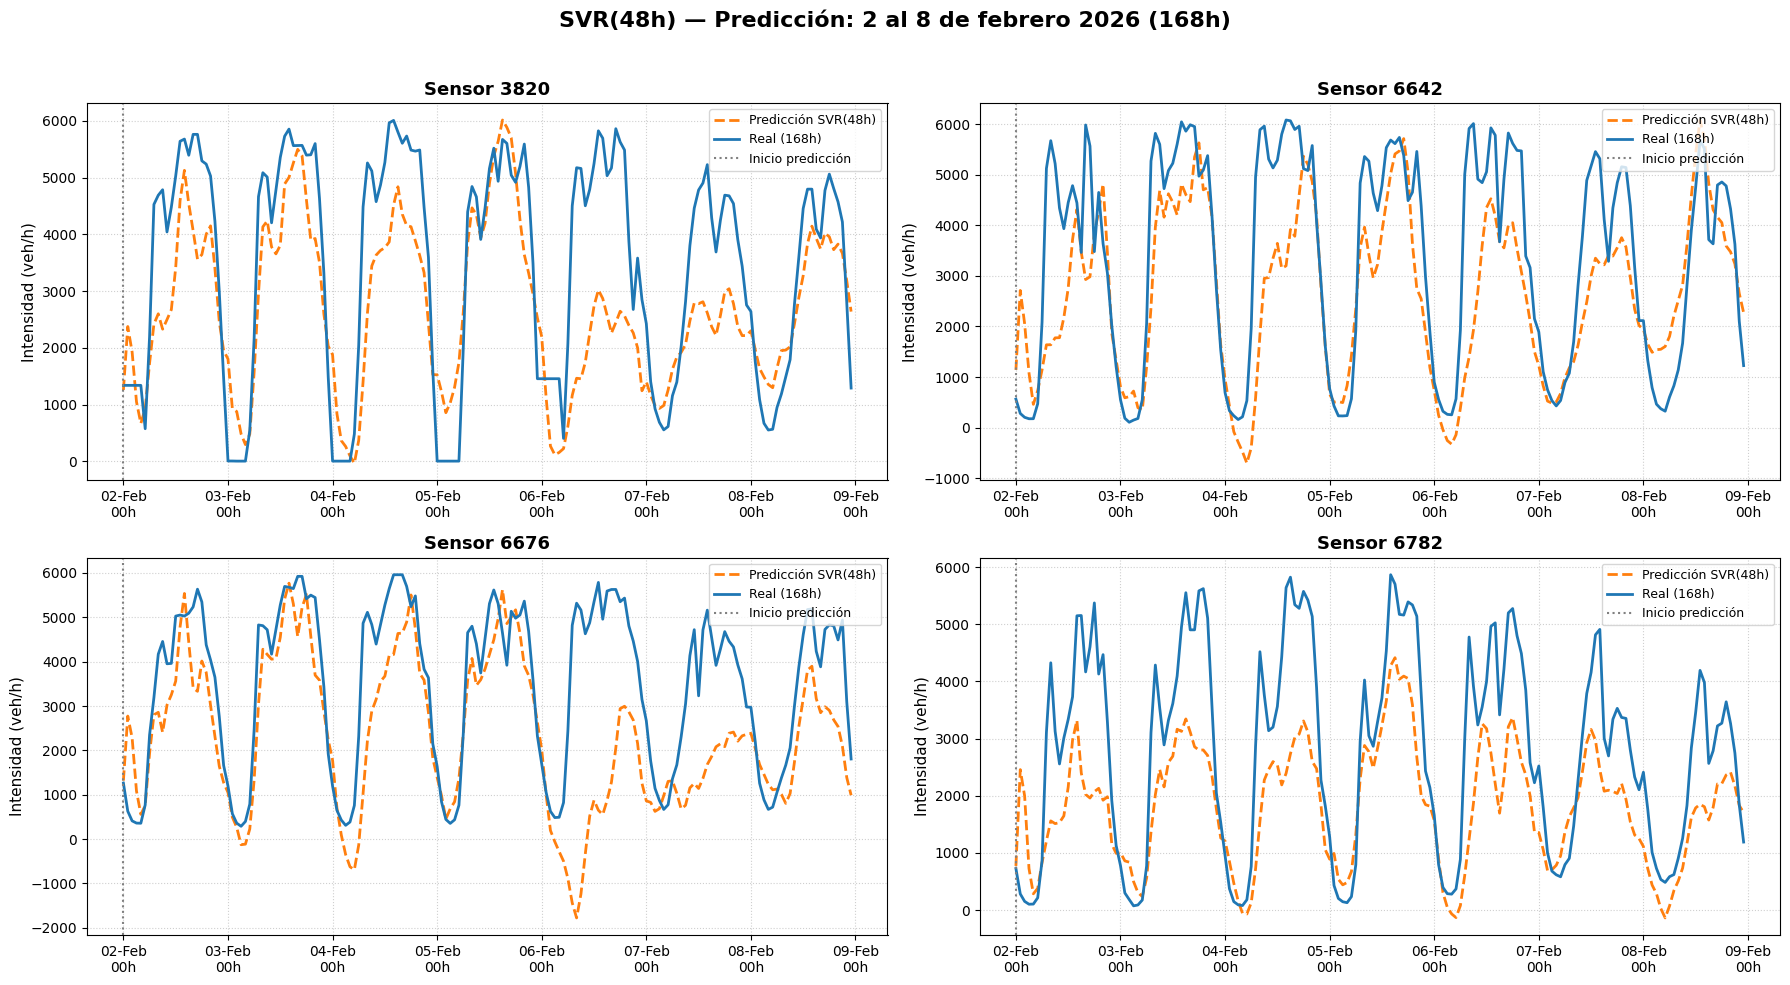

✅ Gráfica generada: SVR(48h)


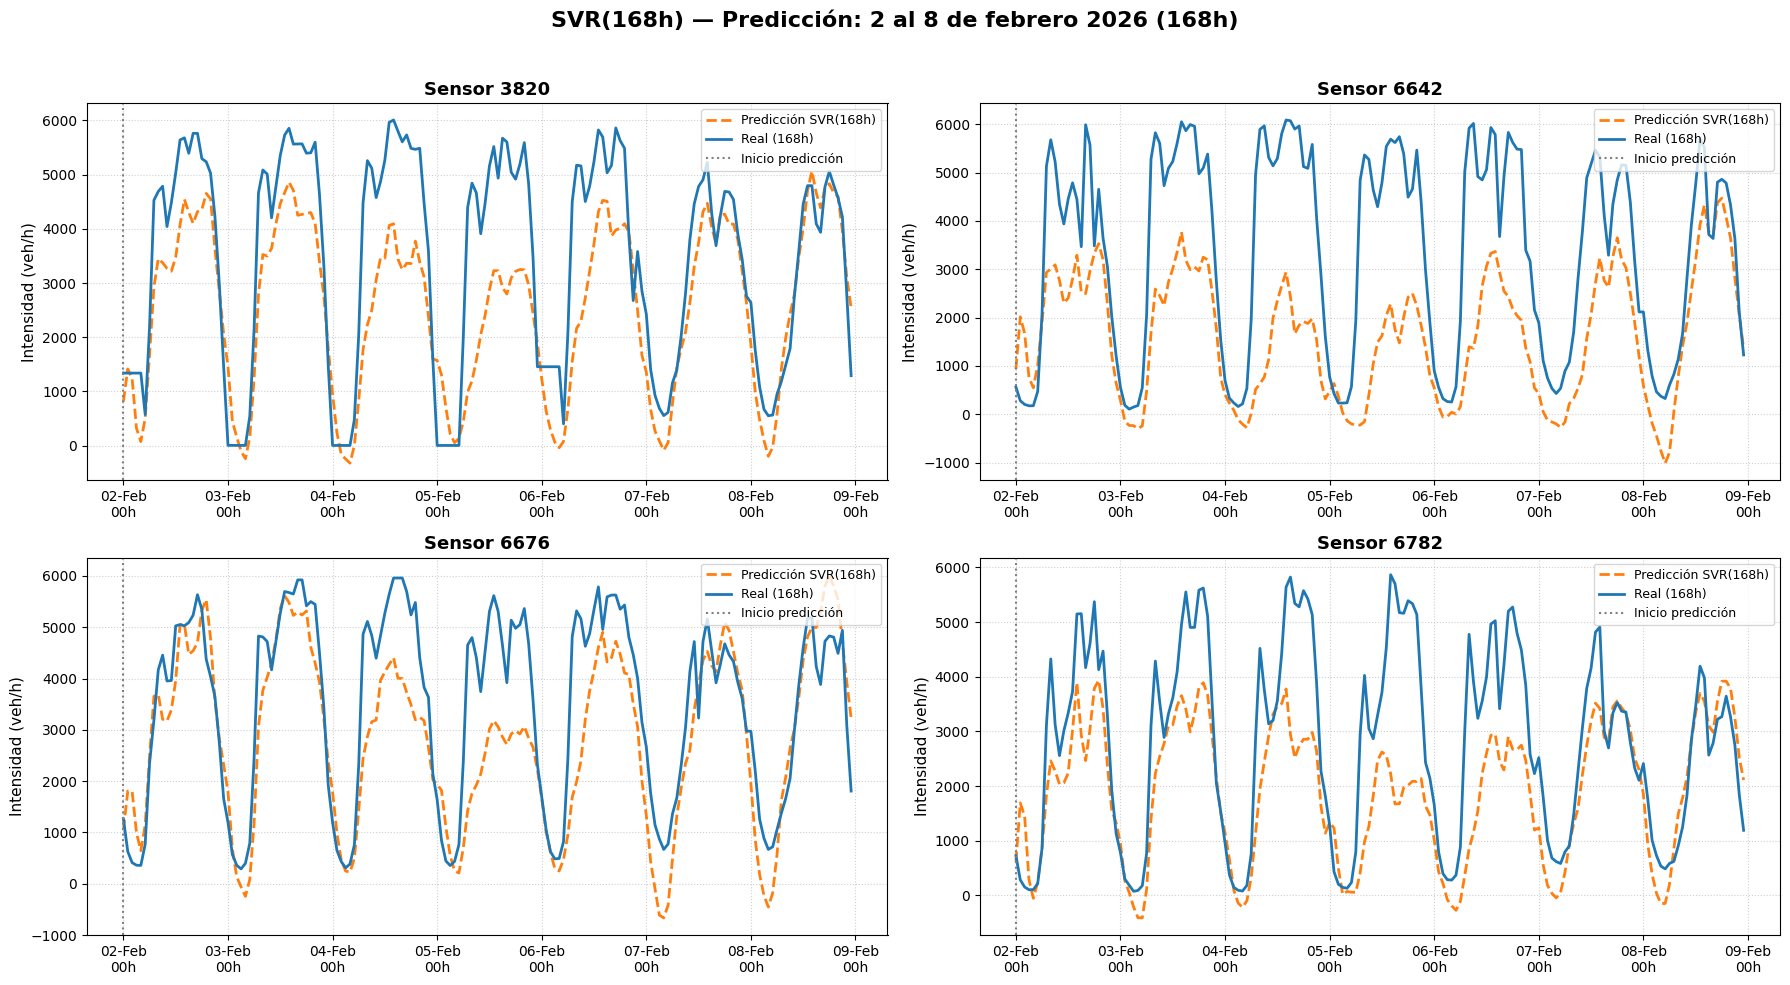

✅ Gráfica generada: SVR(168h)


In [8]:
semana_inicio = pd.Timestamp('2026-02-02 00:00:00')
semana_fin    = pd.Timestamp('2026-02-08 23:00:00')
real_semana   = df_test.loc[semana_inicio:semana_fin, cols_intensidad]

preds_semana = {}
for lag in lags_a_evaluar:
    scaler_X, scaler_y = scalers[lag]
    buffer_inicio = df_val.iloc[-lag:][cols_intensidad].values
    pred = predecir_iterativo_svr(
        modelos_svr[lag], scaler_X, scaler_y, buffer_inicio,
        df_test.loc[semana_inicio:], cols_intensidad, cols_exogenas, lag, steps=168
    )
    idx = pd.date_range(start=semana_inicio, periods=168, freq='h')
    preds_semana[lag] = pd.DataFrame(pred, index=idx, columns=cols_intensidad)

graficar_semana(preds_semana[48], preds_semana[168], real_semana, 'SVR')


In [9]:
pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   --------------------

## 7. Exportación Excel Comparativo

In [10]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
import os

def exportar_excel(resultados_test, nombre_modelo_base, color_48, color_168, ruta_excel):
    """Exporta el Excel comparativo 48h vs 168h según Estilos TFM."""
    os.makedirs(os.path.dirname(ruta_excel), exist_ok=True)
    
    horizontes_nombres = {1: '1_HORA', 24: '24_HORAS', 168: '168_HORAS'}
    horizontes_titulos = {1: '1 HORA', 24: '24 HORAS', 168: '168 HORAS'}
    
    def estilo_titulo(ws, fila, texto):
        ws.merge_cells(start_row=fila, start_column=1, end_row=fila, end_column=7)
        c = ws.cell(row=fila, column=1, value=texto)
        c.font      = Font(bold=True, color='FFFFFF', size=12)
        c.fill      = PatternFill('solid', fgColor='2F4F8F')
        c.alignment = Alignment(horizontal='center', vertical='center')

    def aplicar_borde(cell):
        thin = Side(style='thin')
        cell.border = Border(left=thin, right=thin, top=thin, bottom=thin)

    wb = openpyxl.Workbook()
    wb.remove(wb.active)

    for horizonte in [1, 24, 168]:
        nombre_hoja = horizontes_nombres[horizonte]
        titulo_hoja = horizontes_titulos[horizonte]
        ws = wb.create_sheet(title=nombre_hoja)

        anchos = [16, 12, 12, 12, 12, 12, 12]
        for i, ancho in enumerate(anchos, 1):
            ws.column_dimensions[openpyxl.utils.get_column_letter(i)].width = ancho

        estilo_titulo(ws, 1, f'HORIZONTE: {titulo_hoja} — {nombre_modelo_base}-48h vs {nombre_modelo_base}-168h')
        ws.row_dimensions[1].height = 22

        ws.merge_cells(start_row=2, start_column=2, end_row=2, end_column=4)
        ws.merge_cells(start_row=2, start_column=5, end_row=2, end_column=7)
        for col, texto, color in [(2, f'{nombre_modelo_base}-48h', color_48),
                                   (5, f'{nombre_modelo_base}-168h', color_168)]:
            c = ws.cell(row=2, column=col, value=texto)
            c.font      = Font(bold=True, color='FFFFFF', size=10)
            c.fill      = PatternFill('solid', fgColor=color)
            c.alignment = Alignment(horizontal='center', vertical='center')

        ws.cell(row=3, column=1, value='Sensor').font = Font(bold=True, color='FFFFFF', size=10)
        ws.cell(row=3, column=1).fill                 = PatternFill('solid', fgColor='4472C4')
        ws.cell(row=3, column=1).alignment            = Alignment(horizontal='center')
        for col, metrica in enumerate(['RMSE', 'MAE', 'R²', 'RMSE', 'MAE', 'R²'], 2):
            c = ws.cell(row=3, column=col, value=metrica)
            c.font      = Font(bold=True, color='FFFFFF', size=10)
            c.fill      = PatternFill('solid', fgColor='4472C4')
            c.alignment = Alignment(horizontal='center')

        colores_fila = ['FCE4D6', 'E2EFDA', 'FCE4D6', 'E2EFDA']
        for idx, sensor in enumerate(sensores):
            fila  = 4 + idx
            color = colores_fila[idx]
            m48   = resultados_test[(48,  horizonte)][sensor]
            m168  = resultados_test[(168, horizonte)][sensor]
            
            def fmt_r2(val):
                return round(val, 4) if val is not None else 'N/A'
            
            valores = [sensor,
                       round(m48['RMSE'], 2),  round(m48['MAE'], 2),  fmt_r2(m48['R²']),
                       round(m168['RMSE'], 2), round(m168['MAE'], 2), fmt_r2(m168['R²'])]
            for col, val in enumerate(valores, 1):
                c = ws.cell(row=fila, column=col, value=val)
                c.fill      = PatternFill('solid', fgColor=color)
                c.font      = Font(size=10)
                c.alignment = Alignment(horizontal='center')
                aplicar_borde(c)

        fila_prom = 8
        ws.cell(row=fila_prom, column=1, value='PROMEDIO')
        
        def prom_r2(lag, h):
            vals = [resultados_test[(lag, h)][s]['R²'] for s in sensores if resultados_test[(lag, h)][s]['R²'] is not None]
            return round(sum(vals)/len(vals), 4) if vals else 'N/A'
        
        promedios = [
            round(np.mean([resultados_test[(48,  horizonte)][s]['RMSE'] for s in sensores]), 2),
            round(np.mean([resultados_test[(48,  horizonte)][s]['MAE']  for s in sensores]), 2),
            prom_r2(48, horizonte),
            round(np.mean([resultados_test[(168, horizonte)][s]['RMSE'] for s in sensores]), 2),
            round(np.mean([resultados_test[(168, horizonte)][s]['MAE']  for s in sensores]), 2),
            prom_r2(168, horizonte),
        ]
        for col, val in enumerate([None] + promedios, 1):
            c = ws.cell(row=fila_prom, column=col)
            if col > 1:
                c.value = val
            c.font      = Font(bold=True, size=10)
            c.fill      = PatternFill('solid', fgColor='D9E1F2')
            c.alignment = Alignment(horizontal='center')
            aplicar_borde(c)

    wb.save(ruta_excel)
    print(f"✅ Excel guardado en: {ruta_excel}")


In [11]:
ruta_excel = '../../data/processed/models/5.SVR/comparativa_SVR48_vs_SVR168.xlsx'
exportar_excel(
    resultados_test,
    nombre_modelo_base='SVR',
    color_48='C55A11',   # naranja oscuro
    color_168='375623',  # verde oscuro
    ruta_excel=ruta_excel
)


✅ Excel guardado en: ../../data/processed/models/5.SVR/comparativa_SVR48_vs_SVR168.xlsx
